In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing
df=pd.read_csv("Online Sales Data.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

daily = df['Units Sold']
df

,Transaction ID,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
Date,,,,,,,,
2024-01-01,10001,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
2024-01-02,10002,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal
2024-01-03,10003,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card
2024-01-04,10004,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card
2024-01-05,10005,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal
...,...,...,...,...,...,...,...,...
2024-08-23,10236,Home Appliances,Nespresso Vertuo Next Coffee and Espresso Maker,1,159.99,159.99,Europe,PayPal
2024-08-24,10237,Clothing,Nike Air Force 1 Sneakers,3,90.00,270.00,Asia,Debit Card
2024-08-25,10238,Books,The Handmaid's Tale by Margaret Atwood,3,10.99,32.97,North America,Credit Card


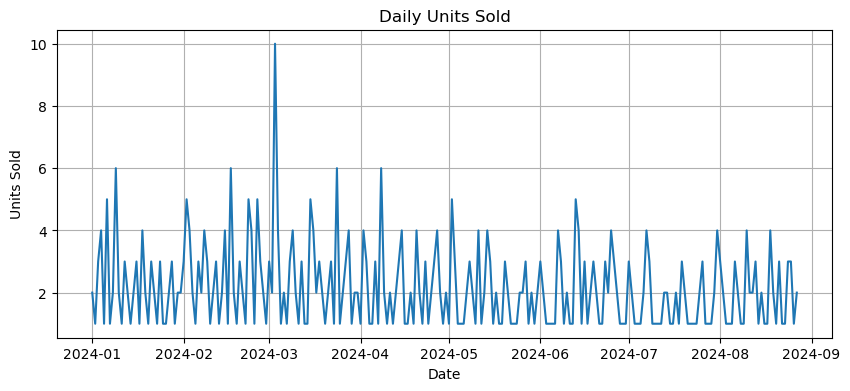

In [4]:
plt.figure(figsize=(10,4))
plt.plot(daily)
plt.title("Daily Units Sold")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.grid(True)
plt.show()
result = seasonal_decompose(daily, model='additive', period=30)

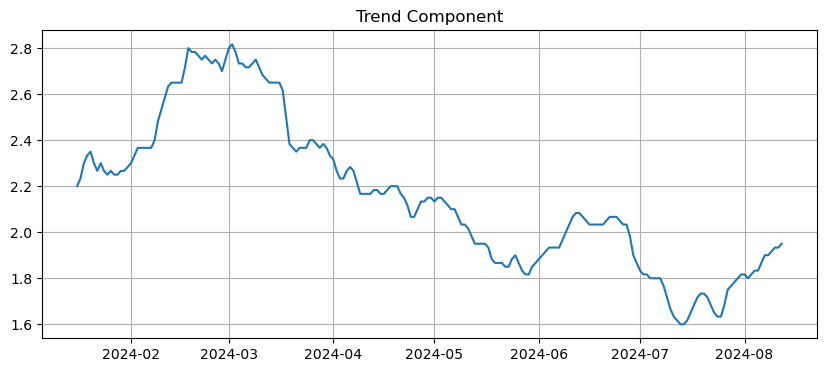

In [5]:
plt.figure(figsize=(10,4))
plt.plot(result.trend)
plt.title("Trend Component")
plt.grid(True)
plt.show()

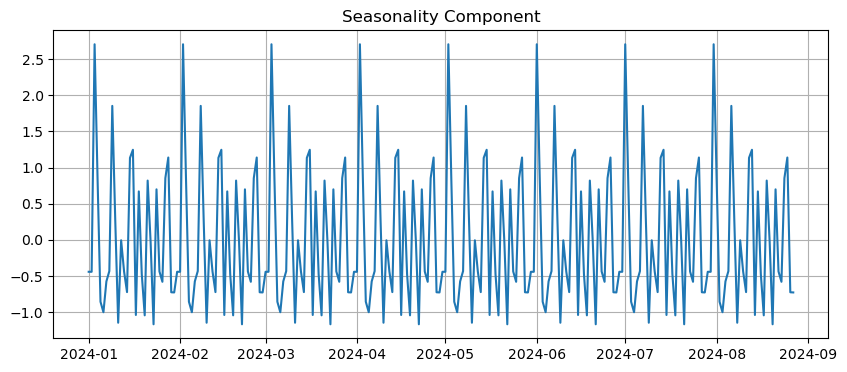

In [6]:
plt.figure(figsize=(10,4))
plt.plot(result.seasonal)
plt.title("Seasonality Component")
plt.grid(True)
plt.show()

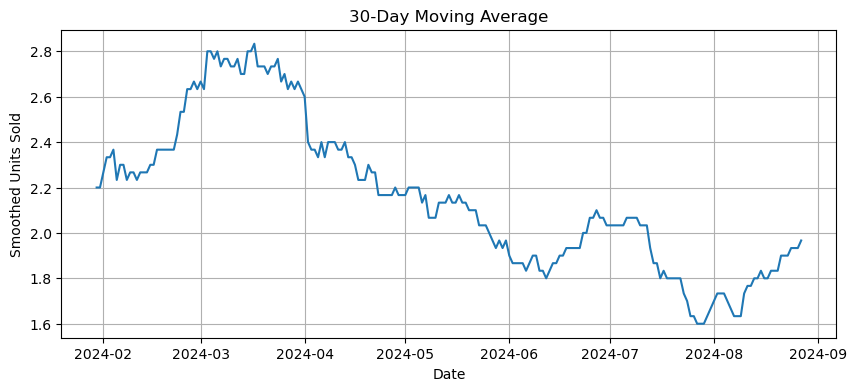

In [7]:
daily_ma = daily.rolling(30).mean()
plt.figure(figsize=(10,4))
plt.plot(daily_ma)
plt.title("30-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Smoothed Units Sold")
plt.grid(True)
plt.show()

In [8]:
adf_result = adfuller(daily.dropna())

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")
for key, val in adf_result[4].items():
    print(f" {key}: {val}")

if adf_result[1] < 0.05:
    print("\nConclusion: The series IS stationary (reject H0).")
else:
    print("\nConclusion: The series is NOT stationary (fail to reject H0).")


ADF Statistic: -1.892732348690971
p-value: 0.3354877294218944
Critical Values:
 1%: -3.4597521044060353
 5%: -2.874472927517147
 10%: -2.5736628197530864

Conclusion: The series is NOT stationary (fail to reject H0).


In [9]:
df = df.asfreq('D')
daily = df['Units Sold']   
model = ExponentialSmoothing(
    daily,
    trend="add",
    seasonal="add",
    seasonal_periods=30
).fit()


In [10]:
forecast = model.forecast(30)


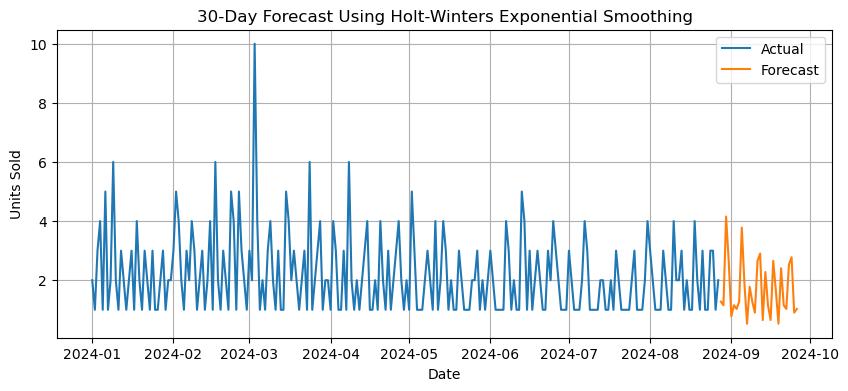

In [11]:
plt.figure(figsize=(10,4))
plt.plot(daily, label="Actual")
plt.plot(forecast, label="Forecast")
plt.title("30-Day Forecast Using Holt-Winters Exponential Smoothing")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.grid(True)
plt.show()

In [13]:

mean_sales = daily.mean()
std_sales = daily.std()

upper_limit = mean_sales + 2*std_sales
lower_limit = mean_sales - 2*std_sales

spikes = daily[daily > upper_limit]
drops = daily[daily < lower_limit]

print("\nSudden Spikes:")
print(spikes)

print("\nSudden Drops:")
print(drops)


Sudden Spikes:
Date
2024-01-06     5
2024-01-09     6
2024-02-02     5
2024-02-17     6
2024-02-23     5
2024-02-26     5
2024-03-03    10
2024-03-15     5
2024-03-24     6
2024-04-08     6
2024-05-02     5
2024-06-13     5
Name: Units Sold, dtype: int64

Sudden Drops:
Series([], Freq: D, Name: Units Sold, dtype: int64)
